**LAB EXPERIMENT - 10**

**Recommendation Systems using Matrix Factorization
(SVD & NMF)**

Name : Poovika M\
Roll No : 24BAD087

**SCENARIO 1**

**CODE INTERPRETATION**


*   Libraries imported for data handling, SVD, evaluation, and visualization

*   MovieLens dataset loaded using read_csv()

*   Ratings and movies data merged and cleaned

*   User-item matrix created using pivot table

*   Mean normalization applied and missing values filled with 0

*   SVD applied to decompose matrix into U, Σ, Vᵀ

*   Latent factors (k) selected for dimensionality reduction
*   Matrix reconstructed using U × Σ × Vᵀ


*   Predicted ratings generated from reconstructed matrix


*   Top N unrated movies recommended to users


*   Model evaluated using RMSE and MAE


*   Effect of different k values analyzed



*   Heatmaps, RMSE plot, and recommendation chart visualized


*   SVD improves recommendation accuracy using latent features



POOVIKA M - 24BAD087

Top Recommendations (SVD):

title
Leaving Las Vegas (1995)        5.103174
Close Shave, A (1995)           4.644203
Casablanca (1942)               4.288601
Sense and Sensibility (1995)    4.220538
Lawrence of Arabia (1962)       4.183741
Name: 1, dtype: float64

Evaluation Metrics:
RMSE: 0.8490412460677765
MAE: 0.6635847235011532


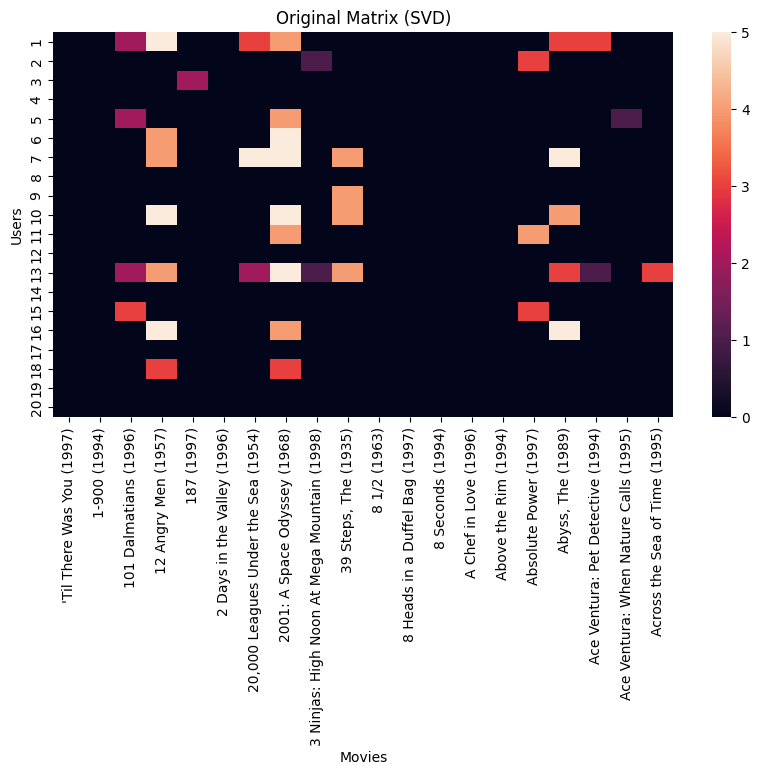

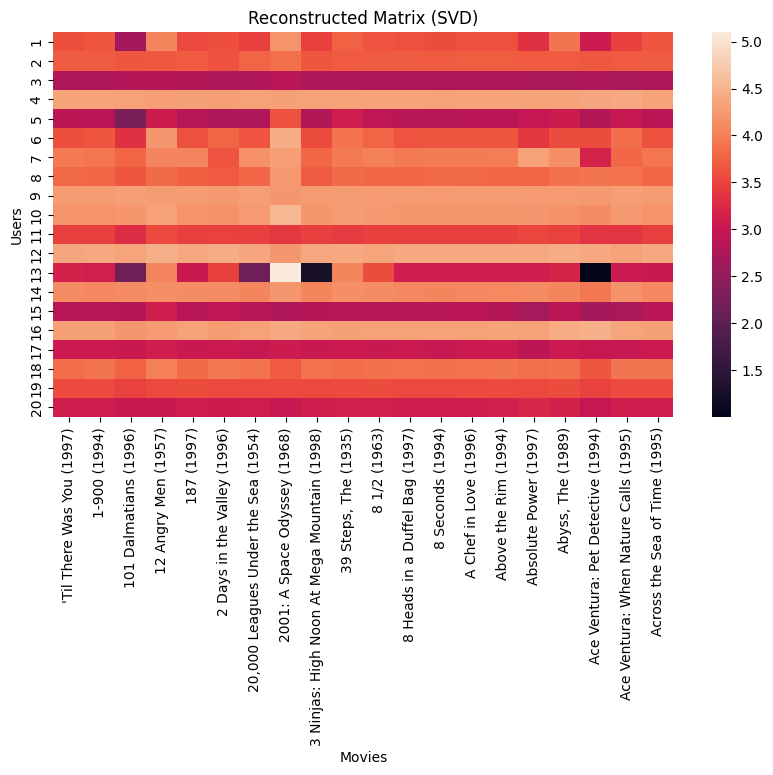

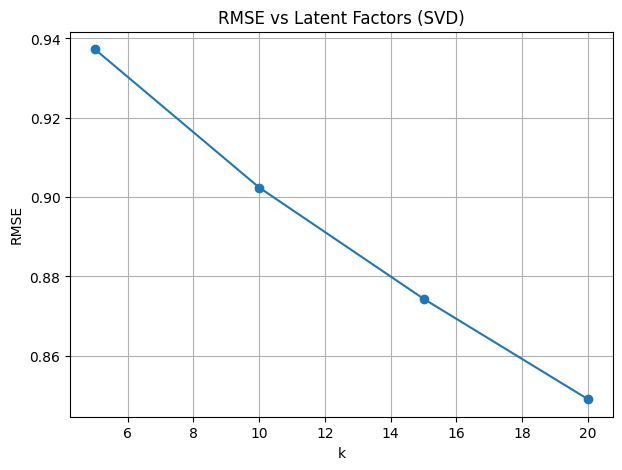

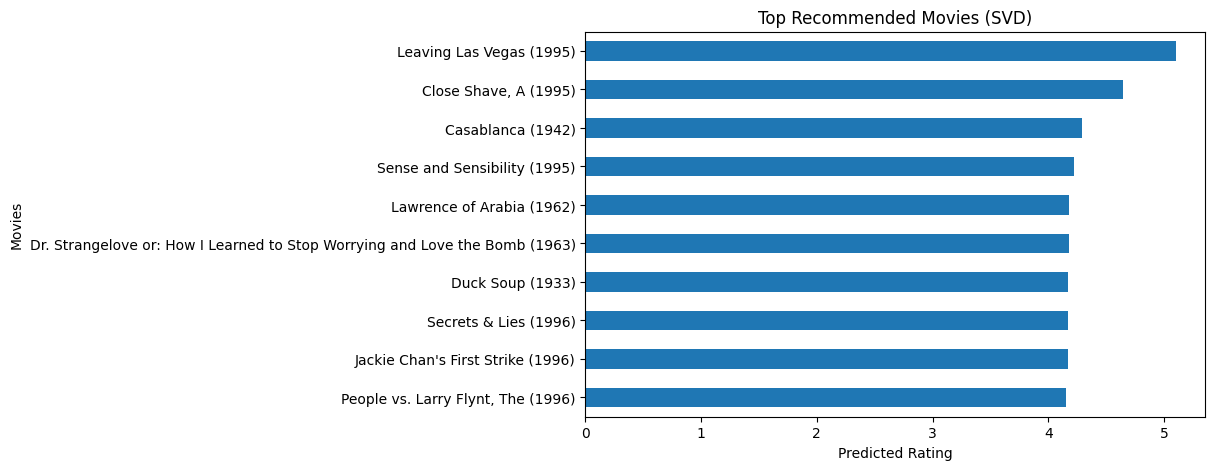

In [1]:
#POOVIKA M - 24BAD087
#SVD MOVIE RECOMMENDATION SYSTEM

print("POOVIKA M - 24BAD087")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error, mean_absolute_error

#Load Dataset
ratings = pd.read_csv("/content/sample_data/u.data",
                      sep='\t',
                      names=["user_id", "movie_id", "rating", "timestamp"])

movies = pd.read_csv("/content/sample_data/u.item",
                     sep='|',
                     encoding='latin-1',
                     header=None)

movies = movies[[0, 1]]
movies.columns = ["movie_id", "title"]

#Preprocessing
data = pd.merge(ratings, movies, on="movie_id")
data = data.drop("timestamp", axis=1)

#User-Item Matrix
user_item_matrix = data.pivot_table(index='user_id',
                                    columns='title',
                                    values='rating')

#Normalize Matrix
user_mean = user_item_matrix.mean(axis=1)

matrix_norm = user_item_matrix.sub(user_mean, axis=0)
matrix_norm = matrix_norm.fillna(0).astype(float)

#SAFE SVD
k = min(20, min(matrix_norm.shape) - 1)

U, sigma, Vt = svds(matrix_norm.values, k=k)

# Sort singular values
idx = np.argsort(sigma)[::-1]
sigma = sigma[idx]
U = U[:, idx]
Vt = Vt[idx, :]

sigma = np.diag(sigma)

#Reconstruction
reconstructed_matrix = np.dot(np.dot(U, sigma), Vt)
reconstructed_matrix += user_mean.values.reshape(-1, 1)

predicted_ratings = pd.DataFrame(reconstructed_matrix,
                                 index=user_item_matrix.index,
                                 columns=user_item_matrix.columns)

#Recommendation Function
def recommend_movies(user_id, n=5):
    user_row = predicted_ratings.iloc[user_id - 1]
    sorted_movies = user_row.sort_values(ascending=False)
    already_rated = user_item_matrix.iloc[user_id - 1].dropna().index
    return sorted_movies.drop(already_rated).head(n)

print("\nTop Recommendations (SVD):\n")
print(recommend_movies(1, 5))

#Evaluation
mask = user_item_matrix.notna().values

actual = user_item_matrix.values[mask]
predicted = predicted_ratings.values[mask]

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("\nEvaluation Metrics:")
print("RMSE:", rmse)
print("MAE:", mae)

#VISUALIZATIONS
#Heatmap
plt.figure(figsize=(10,5))
sns.heatmap(user_item_matrix.fillna(0).iloc[:20,:20])
plt.title("Original Matrix (SVD)")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.show()

plt.figure(figsize=(10,5))
sns.heatmap(predicted_ratings.iloc[:20,:20])
plt.title("Reconstructed Matrix (SVD)")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.show()

#Error vs k
k_values = [5, 10, 15, 20]
rmse_list = []

for k in k_values:
    U, sigma, Vt = svds(matrix_norm.values, k=k)

    idx = np.argsort(sigma)[::-1]
    sigma = sigma[idx]
    U = U[:, idx]
    Vt = Vt[idx, :]

    sigma = np.diag(sigma)

    recon = np.dot(np.dot(U, sigma), Vt)
    recon += user_mean.values.reshape(-1, 1)

    pred = recon[mask]
    rmse_val = np.sqrt(mean_squared_error(actual, pred))
    rmse_list.append(rmse_val)

plt.figure(figsize=(7,5))
plt.plot(k_values, rmse_list, marker='o')
plt.title("RMSE vs Latent Factors (SVD)")
plt.xlabel("k")
plt.ylabel("RMSE")
plt.grid()
plt.show()

#Top Recommendations Chart
top_movies = recommend_movies(1, 10)

plt.figure(figsize=(8,5))
top_movies.sort_values().plot(kind='barh')
plt.title("Top Recommended Movies (SVD)")
plt.xlabel("Predicted Rating")
plt.ylabel("Movies")
plt.show()

**SCENARIO 2**

**CODE INTERPRETATION**


*   Libraries imported for data handling, NMF, evaluation, and visualization

*   MovieLens dataset loaded using read_csv()

*   Ratings and movies data merged and cleaned

*   User-item matrix created using pivot table

*   Missing values filled with 0 for matrix factorization

*   NMF model applied to decompose matrix into W and H

*   k latent features selected for factorization

*   User-feature matrix (W) and item-feature matrix (H) generated
*   Matrix reconstructed using W × H


*   Predicted ratings obtained from reconstructed matrix


*   Top N unrated movies recommended to users


*   Model evaluated using RMSE

*   Recommendation quality measured using Precision@K and Recall@K


*   SVD vs NMF performance and sparsity handling analyzed


*   Latent features, heatmaps, and recommendation charts visualized


*  NMF provides interpretable recommendations using non-negative latent features



POOVIKA M - 24BAD087


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


Top Recommendations (NMF):
title
Close Shave, A (1995)           3.759612
Trainspotting (1996)            3.718698
Sense and Sensibility (1995)    3.612602
Heathers (1989)                 3.549750
Schindler's List (1993)         3.177613
Name: 1, dtype: float64
RMSE: 2.2239225323052207
Precision@5: 0.7253446447507953
Recall@5: 0.11090939217829478


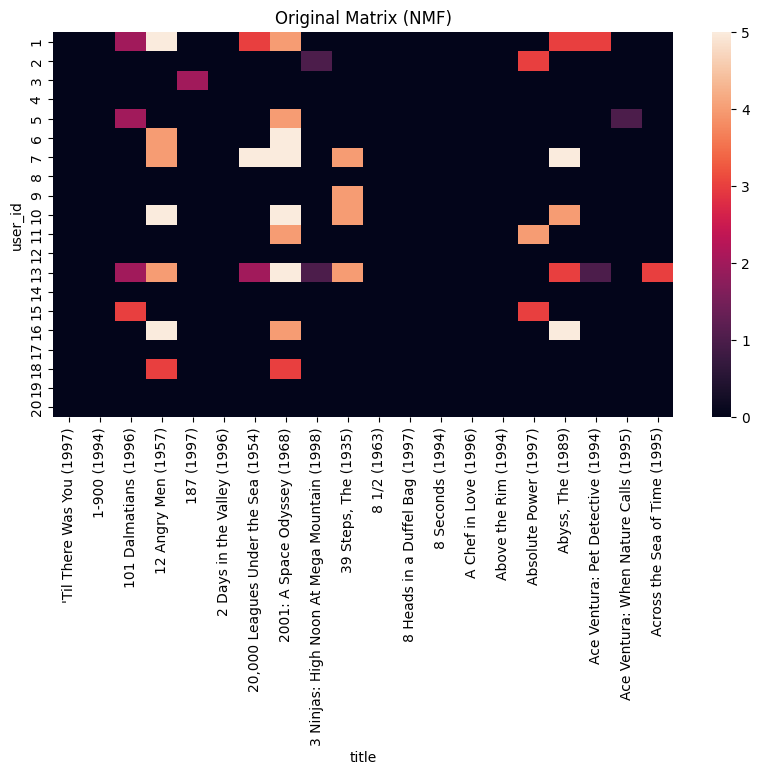

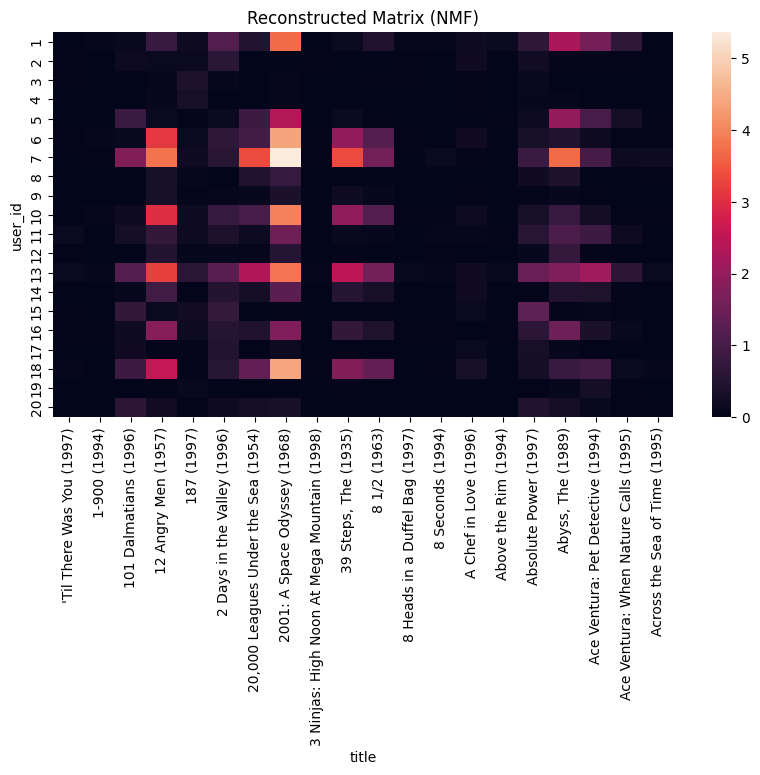

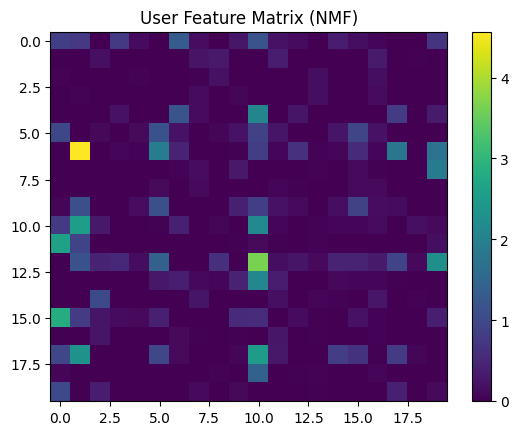

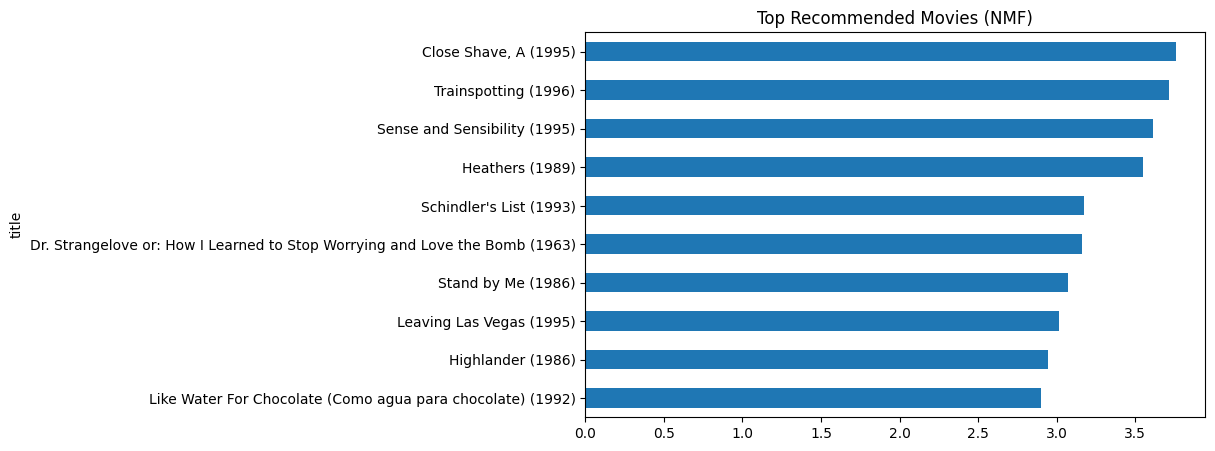

In [3]:
#POOVIKA M - 24BAD087
#NMF MOVIE RECOMMENDATION SYSTEM

print("POOVIKA M - 24BAD087")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

# Load Dataset
ratings = pd.read_csv("/content/sample_data/u.data",
                      sep='\t',
                      names=["user_id", "movie_id", "rating", "timestamp"])

movies = pd.read_csv("/content/sample_data/u.item",
                     sep='|',
                     encoding='latin-1',
                     header=None)

movies = movies[[0, 1]]
movies.columns = ["movie_id", "title"]

# Preprocessing
data = pd.merge(ratings, movies, on="movie_id")
data = data.drop("timestamp", axis=1)

# User-Item Matrix
user_item_matrix = data.pivot_table(index='user_id',
                                    columns='title',
                                    values='rating')

# Fill missing values
matrix_filled = user_item_matrix.fillna(0).astype(float)

# Apply NMF
k = 20
nmf_model = NMF(n_components=k, init='random', random_state=42, max_iter=200)

W = nmf_model.fit_transform(matrix_filled)
H = nmf_model.components_

# Reconstruction
reconstructed_matrix = np.dot(W, H)

predicted_ratings = pd.DataFrame(reconstructed_matrix,
                                 index=user_item_matrix.index,
                                 columns=user_item_matrix.columns)

# Recommendation Function
def recommend_movies(user_id, n=5):
    user_row = predicted_ratings.iloc[user_id - 1]
    sorted_movies = user_row.sort_values(ascending=False)
    already_rated = user_item_matrix.iloc[user_id - 1].dropna().index
    return sorted_movies.drop(already_rated).head(n)

print("Top Recommendations (NMF):")
print(recommend_movies(1, 5))

# Evaluation
mask = user_item_matrix.notna().values
actual = user_item_matrix.values[mask]
predicted = predicted_ratings.values[mask]

rmse = np.sqrt(mean_squared_error(actual, predicted))
print("RMSE:", rmse)

# Precision@K and Recall@K
def precision_recall_at_k(k=5, threshold=3.5):
    precisions, recalls = [], []

    for user in range(user_item_matrix.shape[0]):
        actual_r = user_item_matrix.iloc[user]
        pred_r = predicted_ratings.iloc[user]

        relevant = actual_r[actual_r >= threshold].index
        recommended = pred_r.sort_values(ascending=False).head(k).index

        tp = len(set(recommended) & set(relevant))

        precisions.append(tp / k if k > 0 else 0)
        recalls.append(tp / len(relevant) if len(relevant) > 0 else 0)

    return np.mean(precisions), np.mean(recalls)

p, r = precision_recall_at_k()
print("Precision@5:", p)
print("Recall@5:", r)

#VISUALIZATIONS

# Heatmap
plt.figure(figsize=(10,5))
sns.heatmap(user_item_matrix.fillna(0).iloc[:20,:20])
plt.title("Original Matrix (NMF)")
plt.show()

plt.figure(figsize=(10,5))
sns.heatmap(predicted_ratings.iloc[:20,:20])
plt.title("Reconstructed Matrix (NMF)")
plt.show()

# Latent features
plt.imshow(W[:20,:], aspect='auto')
plt.title("User Feature Matrix (NMF)")
plt.colorbar()
plt.show()

# Top recommendations chart
top_movies = recommend_movies(1, 10)

plt.figure(figsize=(8,5))
top_movies.sort_values().plot(kind='barh')
plt.title("Top Recommended Movies (NMF)")
plt.show()